In [2]:
import requests, json
import pandas as pd
import numpy as np

In [18]:
def RREO(an_exercicio, nr_periodo, co_tipo_demonstrativo, no_anexo, id_ente):
    url = f'https://apidatalake.tesouro.gov.br/ords/siconfi/tt//rreo?an_exercicio={an_exercicio}&nr_periodo={nr_periodo}&co_tipo_demonstrativo={co_tipo_demonstrativo}&no_anexo={no_anexo}&co_esfera=&id_ente={id_ente}'
    response = requests.get(url)
    if(response.status_code != 200): 
            return({result:'Falhou'})
    dados = response.json()
    return pd.DataFrame(dados['items'])

In [138]:
an_exercicio = ['2020','2021','2022','2023','2024']
id_ente = "11" #Código IBGE do Ente.
co_tipo_demonstrativo = 'RREO' #tipo de demonstrativo RREO - Bimestre
nr_periodo = '6' #periodo RREO - Bimestre
no_anexo = ['RREO-Anexo 01','RREO-Anexo 03']

rreo_df = pd.DataFrame()

for i in an_exercicio:
    for j in no_anexo:
        df = RREO(i, nr_periodo, co_tipo_demonstrativo, j, id_ente)
        rreo_df = pd.concat([rreo_df, df])    

In [139]:
drop = rreo_df.columns[1:11]
rreo_df = rreo_df.drop(columns=drop)

rreo_df.sample(3)

,exercicio,coluna,cod_conta,conta,valor
237,2021,% (b/a),ReceitasIntraOrcamentariasTotal,RECEITAS (INTRA-ORÇAMENTÁRIAS) (II),3.855000e+01
291,2023,<MR>,ContribuicaoDoServidorParaOPlanoDePrevidencia,Contrib. do Servidor para o Plano de Previdência,1.103675e+08
203,2022,% (b/a),AlienacaoDeBens,ALIENAÇÃO DE BENS,1.275770e+03


In [140]:
contas_desejadas = [
    'ReceitaDeContribuicoes',
    'ReceitaPatrimonial',
    'ReceitaDeServicos',
    'OutrasReceitasCorrentes',
    'ReceitasIntraOrcamentariasTotal',
    'RREO3TransferenciasCorrentes',
    'ReceitaTributariaLiquidaExcetoTransferenciasEFUNDEB',
]

filtro_df = rreo_df[rreo_df['cod_conta'].isin(contas_desejadas)]

# Agrupando por 'exercicio' e somando os valores
soma_anexo01 = filtro_df.query("coluna == 'Até o Bimestre (c)'").groupby(['exercicio','conta'])['valor'].sum().reset_index()
soma_anexo03 = filtro_df.query("coluna == 'TOTAL (ÚLTIMOS 12 MESES)'").groupby(['exercicio','conta'])['valor'].sum().reset_index()

soma_por_exercicio = pd.concat([soma_anexo01, soma_anexo03]).groupby(['exercicio'])['valor'].sum().reset_index()

soma_por_exercicio['valor_bilhoes'] = (soma_por_exercicio['valor'] / 1000000000).round(2)

soma_por_exercicio

,exercicio,valor,valor_bilhoes
0,2020,1.202286e+10,12.02
1,2021,1.403337e+10,14.03
2,2022,1.666317e+10,16.66
3,2023,1.781297e+10,17.81
4,2024,2.049970e+10,20.50


<Axes: xlabel='exercicio'>

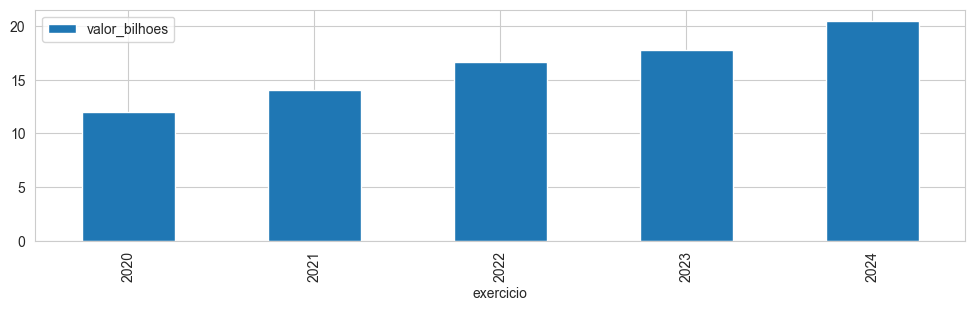

In [141]:
soma_por_exercicio.plot(x= 'exercicio',y='valor_bilhoes', kind='bar',figsize=(12,3))

In [135]:
%pip install seaborn


  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)


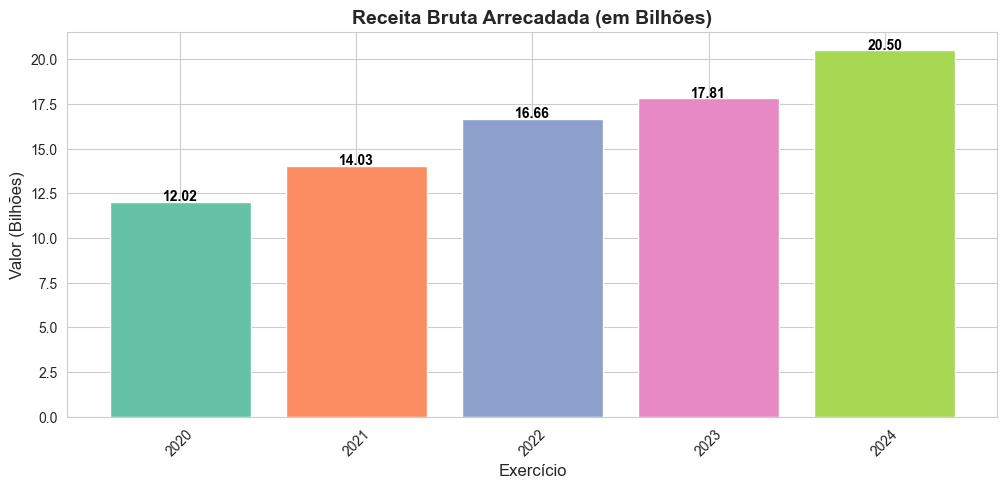

In [142]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configuração do estilo do gráfico
sns.set_style("whitegrid")  # Fundo mais limpo
plt.figure(figsize=(12, 5))  # Ajustando o tamanho

# Criando o gráfico de barras
cores = sns.color_palette("Set2", len(soma_por_exercicio))  # Paleta de cores
plt.bar(soma_por_exercicio['exercicio'], soma_por_exercicio['valor_bilhoes'], color=cores)

# Adicionando rótulos e título
plt.xlabel("Exercício", fontsize=12)
plt.ylabel("Valor (Bilhões)", fontsize=12)
plt.title("Receita Bruta Arrecadada (em Bilhões)", fontsize=14, fontweight="bold")

# Ajustando os rótulos do eixo X
plt.xticks(soma_por_exercicio['exercicio'], rotation=45)

# Adicionando rótulos nas barras
for i, valor in enumerate(soma_por_exercicio['valor_bilhoes']):
    plt.text(soma_por_exercicio['exercicio'][i], valor + 0.05, f"{valor:.2f}", 
             ha='center', fontsize=10, fontweight='bold', color='black')

# Exibindo o gráfico
plt.show()

In [70]:
rreo_df.query("valor > 1000000000")[['coluna','conta','valor']].head(2)

,coluna,conta,valor
0,PREVISÃO INICIAL,RECEITAS (EXCETO INTRA-ORÇAMENTÁRIAS) (I),7.862012e+09
1,PREVISÃO ATUALIZADA (a),RECEITAS (EXCETO INTRA-ORÇAMENTÁRIAS) (I),8.138927e+09


In [72]:
rreo_df.query("conta == 'OUTRAS RECEITAS DE CAPITAL'")[['coluna','conta','valor']].head(2)

,coluna,conta,valor
444,No Bimestre (b),OUTRAS RECEITAS DE CAPITAL,2155433.65
445,Até o Bimestre (c),OUTRAS RECEITAS DE CAPITAL,3416333.65


In [55]:
data = rreo_df.pivot_table(index=['exercicio','conta'], columns='coluna', values='valor', aggfunc='sum')

data.head(3)

coluna                              % (b/a)  % (c/a)  Até o Bimestre (c)  \
exercicio conta                                                            
2019      ALIENAÇÃO DE BENS          226.13   344.55           1264826.6   
          AMORTIZAÇÃO DA DÍVIDA         NaN      NaN                 NaN   
          Alienação de Bens Móveis   226.13   344.55           1264826.6   

coluna                              DESPESAS EMPENHADAS ATÉ O BIMESTRE (f)  \
exercicio conta                                                              
2019      ALIENAÇÃO DE BENS                                            NaN   
          AMORTIZAÇÃO DA DÍVIDA                               1.918664e+08   
          Alienação de Bens Móveis                                     NaN   

coluna                              DESPESAS EMPENHADAS NO BIMESTRE  \
exercicio conta                                                       
2019      ALIENAÇÃO DE BENS                                     NaN   
          AMORTIZAÇÃO DA DÍVIDA                         38923054.28   
          Alienação de Bens Móveis                              NaN   

coluna                              DESPESAS LIQUIDADAS ATÉ O BIMESTRE (h)  \
exercicio conta                                                              
2019      ALIENAÇÃO DE BENS                                            NaN   
          AMORTIZAÇÃO DA DÍVIDA                               1.918664e+08   
          Alienação de Bens Móveis                                     NaN   

coluna                              DESPESAS LIQUIDADAS NO BIMESTRE  \
exercicio conta                                                       
2019      ALIENAÇÃO DE BENS                                     NaN   
          AMORTIZAÇÃO DA DÍVIDA                         38994871.18   
          Alienação de Bens Móveis                              NaN   

coluna                              DESPESAS PAGAS ATÉ O BIMESTRE (j)  \
exercicio conta                                                         
2019      ALIENAÇÃO DE BENS                                       NaN   
          AMORTIZAÇÃO DA DÍVIDA                          1.918664e+08   
          Alienação de Bens Móveis                                NaN   

coluna                              DOTAÇÃO ATUALIZADA (e)  \
exercicio conta                                              
2019      ALIENAÇÃO DE BENS                            NaN   
          AMORTIZAÇÃO DA DÍVIDA                191967244.2   
          Alienação de Bens Móveis                     NaN   

coluna                              DOTAÇÃO INICIAL (d)  \
exercicio conta                                           
2019      ALIENAÇÃO DE BENS                         NaN   
          AMORTIZAÇÃO DA DÍVIDA             139215197.0   
          Alienação de Bens Móveis                  NaN   

coluna                              INSCRITAS EM RESTOS A PAGAR NÃO PROCESSADOS (k)  \
exercicio conta                                                                       
2019      ALIENAÇÃO DE BENS                                                     NaN   
          AMORTIZAÇÃO DA DÍVIDA                                                 NaN   
          Alienação de Bens Móveis                                              NaN   

coluna                              No Bimestre (b)  PREVISÃO ATUALIZADA (a)  \
exercicio conta                                                                
2019      ALIENAÇÃO DE BENS                830126.6                 367100.0   
          AMORTIZAÇÃO DA DÍVIDA                 NaN                      NaN   
          Alienação de Bens Móveis         830126.6                 367100.0   

coluna                              PREVISÃO INICIAL  SALDO (a-c)  \
exercicio conta                                                     
2019      ALIENAÇÃO DE BENS                      NaN    -897726.6   
          AMORTIZAÇÃO DA DÍVIDA                  NaN          NaN   
          Alienação de Bens Móveis     

In [53]:
soma = filtered_data.loc["Alienação de Bens Móveis"].sum()
soma

KeyError: 'Alienação de Bens Móveis'

In [47]:
pip install docx


  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
  Using cached lxml-5.3.1-cp311-cp311-win_amd64.whl.metadata (3.8 kB)
   ---------------------------------------- 0.0/2.6 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.6 MB ? eta -:--:--
   --- ------------------------------------ 0.3/2.6 MB ? eta -:--:--
   ------- -------------------------------- 0.5/2.6 MB 1.0 MB/s eta 0:00:03
   ----------- ---------------------------- 0.8/2.6 MB 1.0 MB/s eta 0:00:02
   --------------- ------------------------ 1.0/2.6 MB 1.1 MB/s eta 0:00:02
   ------------------- -------------------- 1.3/2.6 MB 1.1 MB/s eta 0:00:02
   ----------------------- ---------------- 1.6/2.6 MB 1.1 MB/s eta 0:00:01
   ---------

In [50]:
import docx

doc = docx.Document()

# Add title (heading level 0)
doc.add_heading('Relatorio teste', level=0)

p = doc.add_paragraph(
    f"No exercício de {exercicio}, a receita arrecadada no bimestre foi de R$ {soma_no_bimestre_2024:,.2f} bilhões, "
)

ModuleNotFoundError: No module named 'exceptions'

In [138]:
rreo_df['coluna'] = np.where(rreo_df['coluna'].str.contains('PREVISÃO ATUALIZADA', na=False), 'PREVISÃO ATUALIZADA', rreo_df['coluna'])

In [139]:
rreo_df['coluna'].unique()

array(['<MR-11>', '<MR-10>', '<MR-9>', '<MR-8>', '<MR-7>', '<MR-6>',
       '<MR-5>', '<MR-4>', '<MR-3>', '<MR-2>', '<MR-1>', '<MR>',
       'TOTAL (ÚLTIMOS 12 MESES)', 'PREVISÃO ATUALIZADA'], dtype=object)

In [140]:
receitas_correntes_anexo_03 = [
    'Transferências Correntes',
    'Impostos, Taxas e Contribuições de Melhoria',
]

rc_03 = rreo_df[(rreo_df['conta'].isin(receitas_correntes_anexo_03))& rreo_df['coluna'].isin(['TOTAL (ÚLTIMOS 12 MESES)','PREVISÃO ATUALIZADA'])]


In [141]:
rc_03.pivot_table(index=['exercicio','conta'], columns='coluna', values='valor_bilhoes', aggfunc='sum')

coluna                                                 PREVISÃO ATUALIZADA  \
exercicio conta                                                              
2019      Impostos, Taxas e Contribuições de Melhoria                 4.84   
          Transferências Correntes                                    4.13   
2020      Impostos, Taxas e Contribuições de Melhoria                 4.80   
          Transferências Correntes                                    5.02   
2021      Impostos, Taxas e Contribuições de Melhoria                 5.61   
          Transferências Correntes                                    4.84   
2022      Impostos, Taxas e Contribuições de Melhoria                 7.22   
          Transferências Correntes                                    5.60   
2024      Impostos, Taxas e Contribuições de Melhoria                 9.52   
          Transferências Correntes                                    7.68   

coluna                                                 TOTAL (ÚLTIMOS 12 MESES)  
exercicio conta                                                                  
2019      Impostos, Taxas e Contribuições de Melhoria                      5.00  
          Transferências Correntes                                         4.24  
2020      Impostos, Taxas e Contribuições de Melhoria                      5.38  
          Transferências Correntes                                         4.92  
2021      Impostos, Taxas e Contribuições de Melhoria                      6.91  
          Transferências Correntes                                         5.37  
2022      Impostos, Taxas e Contribuições de Melhoria                      7.37  
          Transferências Correntes                                         6.38  
2024      Impostos, Taxas e Contribuições de Melhoria                      9.34  
          Transferências Correntes                                         7.70

In [142]:
an_exercicio = ['2019','2020','2021','2022','2024']
id_ente = "11" #Código IBGE do Ente.

rreo_df = pd.DataFrame()
co_tipo_demonstrativo = 'RREO' #tipo de demonstrativo RREO - Bimestre
nr_periodo = '6' #periodo RREO - Bimestre
no_anexo = 'RREO-Anexo 01'

for i in an_exercicio:
    dados = RREO(i, nr_periodo, co_tipo_demonstrativo, no_anexo, id_ente)
    df = dados['items']
    df = pd.DataFrame(df)
    rreo_df = pd.concat([rreo_df, df], ignore_index=True)
    rreo_df['valor_bilhoes'] = (rreo_df['valor'] / 1000000000).round(2)

In [143]:
receitas_correntes_anexo_01 = [
    'ReceitaDeContribuicoes',
    'ReceitaPatrimonial',
    'ReceitaDeServicos',
    'OutrasReceitasCorrentes',
    'ReceitasIntraOrcamentariasTotal'
]

rc_01 = rreo_df[ (rreo_df['cod_conta'].isin(receitas_correntes_anexo_01))
                 & (rreo_df['coluna'].isin(['Até o Bimestre (c)']))]

In [144]:
rc_01.pivot_table(index=['exercicio','conta'], columns='coluna', values='valor_bilhoes', aggfunc='sum')

coluna                                         Até o Bimestre (c)
exercicio conta                                                  
2019      CONTRIBUIÇÕES                                      0.36
          OUTRAS RECEITAS CORRENTES                          0.27
          RECEITA DE SERVIÇOS                                0.28
          RECEITA PATRIMONIAL                                0.36
          RECEITAS (INTRA-ORÇAMENTÁRIAS) (II)                0.35
2020      CONTRIBUIÇÕES                                      0.36
          OUTRAS RECEITAS CORRENTES                          0.26
          RECEITA DE SERVIÇOS                                0.28
          RECEITA PATRIMONIAL                                0.40
          RECEITAS (INTRA-ORÇAMENTÁRIAS) (II)                0.43
2021      CONTRIBUIÇÕES                                      0.38
          OUTRAS RECEITAS CORRENTES                          0.31
          RECEITA DE SERVIÇOS                                0.35
          RECEITA PATRIMONIAL                                0.36
          RECEITAS (INTRA-ORÇAMENTÁRIAS) (II)                0.36
2022      CONTRIBUIÇÕES                                      0.49
          OUTRAS RECEITAS CORRENTES                          0.41
          RECEITA DE SERVIÇOS                                0.42
          RECEITA PATRIMONIAL                                0.88
          RECEITAS (INTRA-ORÇAMENTÁRIAS) (II)                0.71
2024      CONTRIBUIÇÕES                                      0.62
          OUTRAS RECEITAS CORRENTES                          0.58
          RECEITA DE SERVIÇOS                                0.49
          RECEITA PATRIMONIAL                                0.65
          RECEITAS (INTRA-ORÇAMENTÁRIAS) (II)                1.12

In [150]:
total_rc_01 = rc_01[(rc_01['coluna'] == 'Até o Bimestre (c)')&(rc_01['exercicio'] == 2024)]['valor_bilhoes'].sum()
total_rc_03 = rc_03[(rc_03['coluna'] == 'TOTAL (ÚLTIMOS 12 MESES)')&(rc_03['exercicio'] == 2024)]['valor_bilhoes'].sum()
print(total_rc_01)
print(total_rc_03)
total_rc = total_rc_01 + total_rc_03
print(total_rc)


3.46
17.04
20.5


In [ ]:
#Receitas correntes

receitas_correntes_anexo_01 = [
    'CONTRIBUIÇÕES',
 'RECEITA PATRIMONIAL',
 'RECEITA DE SERVIÇOS',
 'OUTRAS RECEITAS CORRENTES',
 'RECEITAS (INTRA-ORÇAMENTÁRIAS) (II)'
]

receitas_correntes_anexo_03 = [
    'Transferências Correntes',
    'Impostos, Taxas e Contribuições de Melhoria',
]


#'OPERAÇÕES DE CRÉDITO',
#'ALIENAÇÃO DE BENS',
#'TRANSFERÊNCIAS DE CAPITAL',
#'OUTRAS RECEITAS DE CAPITAL',
#'Transferências Constitucionais e Legais',
#'Dedução de Receita para Formação do FUNDEB'





receitas_correntes = pd.concat([df_01, df_03], ignore_index=True)

receitas_correntes['valor_bilhoes'] = (receitas_correntes['valor'] / 1000000000).round(2)

receitas_correntes.pivot_table(index='conta', columns='anexo', values='valor_bilhoes', aggfunc='sum')



anexo,RREO-Anexo 01
conta,
CONTRIBUIÇÕES,3.54
OUTRAS RECEITAS CORRENTES,2.40
RECEITA DE SERVIÇOS,1.62
RECEITA PATRIMONIAL,2.29
RECEITAS (INTRA-ORÇAMENTÁRIAS) (II),5.24


In [64]:
df_03

,exercicio,demonstrativo,periodo,periodicidade,instituicao,cod_ibge,uf,populacao,anexo,esfera,rotulo,coluna,cod_conta,conta,valor,valor_bilhoes
